In [1]:
import torch
from tqdm.auto import tqdm
import os

from src.models.reid import ReIDModel
from src.utils.segment_info import get_segment_groups, get_attention_groups, get_default_thresholds
from src.metric import SimilarityMetric, AllSimilarityMetrics

from IPython.display import clear_output

In [2]:
print("Cuda Available:", torch.cuda.is_available())
print("Cuda Current Device:", torch.cuda.current_device())

Cuda Available: True
Cuda Current Device: 0


In [3]:
# Parameters
class Config:
    device = torch.device("cuda")

    batch_size = 32

    # Model Hyperparameters
    model_variant = "m3small" # "m3large", "m3small", "hr"
    seg_variant = "5a" # "2a", "4a", "5a"
    emb_len = 24
    input_resolution= (192, 64)

    segment_groups = get_segment_groups(seg_variant)
    segment_num = len(segment_groups)
    attention_groups = get_attention_groups(seg_variant)
    attention_num = len(attention_groups)
    default_thresholds = get_default_thresholds(seg_variant)

    similarity_metric = "weighted_geometric_mean" # "weakest_link", "weighted_mean", "weighted_geometric_mean", "minimum"
    similarity_func = SimilarityMetric(similarity_metric, default_thresholds)
    all_similarity = AllSimilarityMetrics(default_thresholds)

    input_name = "input"
    v_score_name = "visibility_scores"
    emb_vec_name = "embedding_vectors"

## Train Model

In [4]:
from torch.optim import lr_scheduler, Adam

from src.data import get_seg_dataloaders, get_re_id_dataloaders, get_bb_dataloaders
from src.data.reid import get_dataset as get_re_id_dataset
from src.loss.seg_loss import SegLoss
from src.loss.class_loss import ClassLoss
from src.loss.triplet_loss import TripletLoss

In [5]:
class TrainConfig:
    learning_rate = 1e-3
    batch_id = 4
    batch_image = 4
    
    resume_type = None # None, "backbone", "seg", "reid"
    resume_epoch = 41
    backbone_epoch = 200
    seg_epoch = 200
    re_id_epoch = 200
    
    epoch_save_steps = 100
    seed = 21

In [6]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=False,
                  backbone_pretrained=True).to(Config.device)

val_generator = torch.Generator()

In [7]:
class_num = len(get_re_id_dataset(Config.input_resolution,
                                  "train")
                .unique_ids)
train_model = model.get_train_model(class_num).to(Config.device)


if TrainConfig.resume_type == "seg":
    print(f"Resume from seg_{TrainConfig.resume_epoch}")
    weight_path = train_model.weight_file_path.format(f"seg_{TrainConfig.resume_epoch}")
    train_model.load_state_dict(torch.load(weight_path, weights_only=True))
elif TrainConfig.resume_type == "reid":
    print(f"Resume from reid_{TrainConfig.resume_epoch}")
    weight_path = train_model.weight_file_path.format(f"reid_{TrainConfig.resume_epoch}")
    train_model.load_state_dict(torch.load(weight_path, weights_only=True))
elif TrainConfig.resume_type == "backbone":
    print(f"Resume from backbone_{TrainConfig.resume_epoch}")
    weight_path = train_model.weight_file_path.format(f"backbone_{TrainConfig.resume_epoch}")
    train_model.load_state_dict(torch.load(weight_path, weights_only=True))

### Train Backbone

In [8]:
bb_optimizer = Adam(train_model.parameters(), lr=TrainConfig.learning_rate, weight_decay=5e-4, amsgrad=True)
bb_scheduler = lr_scheduler.ReduceLROnPlateau(bb_optimizer, patience=5, factor=0.5)

bb_last_epoch = TrainConfig.resume_epoch if TrainConfig.resume_type == "backbone" else 0
bb_last_train_loss = None
bb_last_val_loss = None

bb_best_epoch = None
bb_best_loss = None
bb_best_weight = None

seg_loss = SegLoss()
cls_loss = ClassLoss()
tpl_loss = TripletLoss()

bb_train_dataloaders, bb_val_dataloaders = get_bb_dataloaders(Config.seg_variant,
                                                              Config.input_resolution,
                                                              TrainConfig.batch_id,
                                                              TrainConfig.batch_image,
                                                              val_generator)

loading annotations into memory...
Done (t=9.25s)
creating index...
index created!
loading annotations into memory...
Done (t=1.14s)
creating index...
index created!


In [9]:
def bb_train(epoch):
    global bb_last_train_loss

    train_model.train()
    print(f"Training Epoch: {epoch}")
    train_loss = 0
    train_count = 0
    for (seg_img, seg_label), (re_id_img, id_label) in zip(*bb_train_dataloaders):
        seg_img = seg_img.to(Config.device)
        seg_label = seg_label.to(Config.device)

        re_id_img = re_id_img.to(Config.device)
        id_label = id_label.to(Config.device)

        bb_optimizer.zero_grad()
        out_seg, _, _, _ = train_model(seg_img)
        _, v_score, emb_vec, cls_logits = train_model(re_id_img)

        s_loss = seg_loss(out_seg, seg_label)
        c_loss = cls_loss(cls_logits, id_label)
        t_loss = tpl_loss(v_score, emb_vec, id_label)

        loss = s_loss + c_loss + t_loss

        print('\rSeg_Loss:%.2f  Triplet_Loss:%.2f  Class_Loss:%.2f' % (
            s_loss.data.cpu().numpy(),
            t_loss.data.cpu().numpy(),
            c_loss.data.cpu().numpy()),
              end=' ')

        loss.backward()
        bb_optimizer.step()

        train_loss += loss.item() * seg_img.shape[0]
        train_count += seg_img.shape[0]

    train_loss = train_loss / train_count
    print(f"\nTrain loss: {train_loss:.2f}")
    bb_last_train_loss = train_loss


def bb_val(epoch):
    global bb_best_epoch
    global bb_best_loss
    global bb_best_weight
    global bb_last_val_loss

    val_generator.manual_seed(TrainConfig.seed)
    train_model.eval()
    print(f"Validation on Epoch {epoch}")
    val_loss = 0
    val_count = 0
    with torch.no_grad():
        for (seg_img, seg_label), (re_id_img, id_label) in zip(*bb_val_dataloaders):
            seg_img = seg_img.to(Config.device)
            seg_label = seg_label.to(Config.device)
    
            re_id_img = re_id_img.to(Config.device)
            id_label = id_label.to(Config.device)

            out_seg, _, _, _ = train_model(seg_img)
            _, v_score, emb_vec, _ = train_model(re_id_img)
    
            s_loss = seg_loss(out_seg, seg_label)
            t_loss = tpl_loss(v_score, emb_vec, id_label)
            loss = s_loss + t_loss
    
            print('\rSeg_Loss:%.2f  Triplet_Loss:%.2f' % (
                s_loss.data.cpu().numpy(),
                t_loss.data.cpu().numpy()),
                  end=' ')

            val_loss += loss.item() * seg_img.shape[0]
            val_count += seg_img.shape[0]

    val_loss = val_loss / val_count
    print(f"\nValidation loss: {val_loss:.2f}")
    bb_last_val_loss = val_loss

    if bb_best_loss is None or bb_best_loss > val_loss:
        bb_best_loss = val_loss
        bb_best_epoch = epoch
        bb_best_weight = train_model.state_dict()

    return val_loss

In [10]:
train_model.train_backbone()

bb_val(bb_last_epoch)
clear_output(wait=True)

for cur_epoch in range(bb_last_epoch + 1, TrainConfig.backbone_epoch + 1):
    try:
        print(f"---- Training Backbone {cur_epoch}/{TrainConfig.backbone_epoch} epoch ----")
        print(f"Current best epoch: {bb_best_epoch}")
        print(f"Current best loss: {bb_best_loss:.2f}")
        if bb_last_train_loss is not None:
            print(f"Last train loss: {bb_last_train_loss:.2f}")
        print(f"Last Validation loss: {bb_last_val_loss:.2f}")

        bb_train(cur_epoch)
        val_loss = bb_val(cur_epoch)

        bb_scheduler.step(val_loss)

        bb_last_epoch = cur_epoch

        if cur_epoch % TrainConfig.epoch_save_steps == 0 or cur_epoch == TrainConfig.backbone_epoch:
            weight_file_path = train_model.weight_file_path.format(f"backbone_{cur_epoch}")
            os.makedirs(os.path.dirname(weight_file_path), exist_ok=True)
            torch.save(train_model.state_dict(), weight_file_path)
            print("Checkpoint Saved")

        clear_output(wait=True)

    except KeyboardInterrupt:
        clear_output(wait=True)
        print(f"\nTraining Stopped at epoch {cur_epoch}")
        break

---- Training Backbone 200/200 epoch ----
Current best epoch: 182
Current best loss: 89.22
Last train loss: 82.17
Last Validation loss: 89.44
Training Epoch: 200
Seg_Loss:104.26  Triplet_Loss:0.55  Class_Loss:0.42 
Train loss: 83.42
Validation on Epoch 200
Seg_Loss:112.18  Triplet_Loss:0.50 
Validation loss: 89.62
Checkpoint Saved


In [11]:
print(f"Best epoch: {bb_best_epoch}")
print(f"Best loss: {bb_best_loss:.2f}")
os.makedirs(os.path.dirname(train_model.weight_file_path), exist_ok=True)
torch.save(bb_best_weight, train_model.weight_file_path.format(f"backbone_{bb_best_epoch}"))
torch.save(bb_best_weight, train_model.weight_file_path.format(f"backbone_{bb_best_epoch}_best_{bb_best_loss:.2f}"))
train_model.load_state_dict(bb_best_weight)

Best epoch: 182
Best loss: 89.22


<All keys matched successfully>

### Train Segmentation

In [8]:
seg_optimizer = Adam(train_model.parameters(), lr=TrainConfig.learning_rate, weight_decay=5e-4, amsgrad=True)
seg_scheduler = lr_scheduler.ReduceLROnPlateau(seg_optimizer, patience=5, factor=0.5)

seg_last_epoch = TrainConfig.resume_epoch if TrainConfig.resume_type == "seg" else 0
seg_last_train_loss = None
seg_last_val_loss = None

seg_best_epoch = None
seg_best_loss = None
seg_best_weight = None

seg_loss = SegLoss()

seg_train_dataloader, seg_val_dataloader = get_seg_dataloaders(Config.seg_variant,
                                                               Config.input_resolution,
                                                               TrainConfig.batch_id*TrainConfig.batch_image)

loading annotations into memory...
Done (t=6.68s)
creating index...
index created!
loading annotations into memory...
Done (t=0.97s)
creating index...
index created!


In [9]:
def seg_train(epoch):
    global seg_last_train_loss

    train_model.train()
    print(f"Training Epoch: {epoch}")
    train_loss = 0
    train_count = 0
    for seg_img, seg_label in seg_train_dataloader:
        seg_img = seg_img.to(Config.device)
        seg_label = seg_label.to(Config.device)

        seg_optimizer.zero_grad()
        out_seg, _, _, _ = train_model(seg_img)

        s_loss = seg_loss(out_seg, seg_label)

        print('\rSeg_Loss:%.2f' % (
            s_loss.data.cpu().numpy()),
              end=' ')

        s_loss.backward()
        seg_optimizer.step()

        train_loss += s_loss.item() * seg_img.shape[0]
        train_count += seg_img.shape[0]

    train_loss = train_loss / train_count
    print(f"\nTrain loss: {train_loss:.2f}")
    seg_last_train_loss = train_loss


def seg_val(epoch):
    global seg_best_epoch
    global seg_best_loss
    global seg_best_weight
    global seg_last_val_loss

    train_model.eval()
    print(f"Validation on Epoch {epoch}")
    val_loss = 0
    val_count = 0
    with torch.no_grad():
        for seg_img, seg_label in seg_val_dataloader:
            seg_img = seg_img.to(Config.device)
            seg_label = seg_label.to(Config.device)

            out_seg, _, _, _ = train_model(seg_img)

            s_loss = seg_loss(out_seg, seg_label)

            print('\rSeg_Loss:%.2f' % (
                s_loss.data.cpu().numpy()),
                  end=' ')

            val_loss += s_loss.item() * seg_img.shape[0]
            val_count += seg_img.shape[0]

    val_loss = val_loss / val_count
    print(f"\nValidation loss: {val_loss:.2f}")
    seg_last_val_loss = val_loss

    if seg_best_loss is None or seg_best_loss > val_loss:
        seg_best_loss = val_loss
        seg_best_epoch = epoch
        seg_best_weight = train_model.state_dict()

    return val_loss

In [10]:
train_model.train_segmentation()

seg_val(seg_last_epoch)
clear_output(wait=True)

for cur_epoch in range(seg_last_epoch + 1, TrainConfig.seg_epoch + 1):
    try:
        print(f"---- Training Segmentation {cur_epoch}/{TrainConfig.seg_epoch} epoch ----")
        print(f"Current best epoch: {seg_best_epoch}")
        print(f"Current best loss: {seg_best_loss:.2f}")
        if seg_last_train_loss is not None:
            print(f"Last train loss: {seg_last_train_loss:.2f}")
        print(f"Last Validation loss: {seg_last_val_loss:.2f}")

        seg_train(cur_epoch)
        val_loss = seg_val(cur_epoch)

        seg_scheduler.step(val_loss)

        seg_last_epoch = cur_epoch

        if cur_epoch % TrainConfig.epoch_save_steps == 0 or cur_epoch == TrainConfig.seg_epoch:
            weight_file_path = train_model.weight_file_path.format(f"seg_{cur_epoch}")
            os.makedirs(os.path.dirname(weight_file_path), exist_ok=True)
            torch.save(train_model.state_dict(), weight_file_path)
            print("Checkpoint Saved")

        clear_output(wait=True)

    except KeyboardInterrupt:
        clear_output(wait=True)
        print(f"\nTraining Stopped at epoch {cur_epoch}")
        break


Training Stopped at epoch 72


In [11]:
print(f"Best epoch: {seg_best_epoch}")
print(f"Best loss: {seg_best_loss:.2f}")
os.makedirs(os.path.dirname(train_model.weight_file_path), exist_ok=True)
torch.save(seg_best_weight, train_model.weight_file_path.format(f"seg_{seg_best_epoch}"))
torch.save(seg_best_weight, train_model.weight_file_path.format(f"seg_{seg_best_epoch}_best_{seg_best_loss:.2f}"))
train_model.load_state_dict(seg_best_weight)

Best epoch: 41
Best loss: 80.29


<All keys matched successfully>

### Train Re-ID

In [8]:
re_id_optimizer = Adam(train_model.parameters(), lr=TrainConfig.learning_rate, weight_decay=5e-4, amsgrad=True)
re_id_scheduler = lr_scheduler.ReduceLROnPlateau(re_id_optimizer, patience=5, factor=0.5)

re_id_last_epoch = TrainConfig.resume_epoch if TrainConfig.resume_type == "reid" else 0
re_id_last_train_loss = None
re_id_last_val_loss = None

re_id_best_epoch = None
re_id_best_loss = None
re_id_best_weight = None

cls_loss = ClassLoss()
tpl_loss = TripletLoss()

re_id_train_dataloader, re_id_val_dataloader = get_re_id_dataloaders(Config.input_resolution,
                                                                     TrainConfig.batch_id,
                                                                     TrainConfig.batch_image,
                                                                     val_generator)

In [9]:
def re_id_train(epoch):
    global re_id_last_train_loss

    train_model.train()
    print(f"Training Epoch: {epoch}")
    train_loss = 0
    train_count = 0
    for re_id_img, id_label in re_id_train_dataloader:
        re_id_img = re_id_img.to(Config.device)
        id_label = id_label.to(Config.device)

        re_id_optimizer.zero_grad()
        _, v_score, emb_vec, cls_logits = train_model(re_id_img)

        c_loss = cls_loss(cls_logits, id_label)
        t_loss = tpl_loss(v_score, emb_vec, id_label)

        loss = c_loss + t_loss

        print('\rTriplet_Loss:%.2f  Class_Loss:%.2f' % (
            t_loss.data.cpu().numpy(),
            c_loss.data.cpu().numpy()),
              end=' ')

        loss.backward()
        re_id_optimizer.step()

        train_loss += loss.item() * re_id_img.shape[0]
        train_count += re_id_img.shape[0]

    train_loss = train_loss / train_count
    print(f"\nTrain loss: {train_loss:.2f}")
    re_id_last_train_loss = train_loss


def re_id_val(epoch):
    global re_id_best_epoch
    global re_id_best_loss
    global re_id_best_weight
    global re_id_last_val_loss

    val_generator.manual_seed(TrainConfig.seed)
    train_model.eval()
    print(f"Validation on Epoch {epoch}")
    val_loss = 0
    val_count = 0
    with torch.no_grad():
        for re_id_img, id_label in re_id_val_dataloader:
            re_id_img = re_id_img.to(Config.device)
            id_label = id_label.to(Config.device)

            _, v_score, emb_vec, _ = train_model(re_id_img)

            loss = tpl_loss(v_score, emb_vec, id_label)

            print('\rTriplet_Loss:%.2f' % (
                loss.data.cpu().numpy()),
                  end=' ')

            val_loss += loss.item() * re_id_img.shape[0]
            val_count += re_id_img.shape[0]

    val_loss = val_loss / val_count
    print(f"\nValidation loss: {val_loss:.2f}")
    re_id_last_val_loss = val_loss

    if re_id_best_loss is None or re_id_best_loss > val_loss:
        re_id_best_loss = val_loss
        re_id_best_epoch = epoch
        re_id_best_weight = train_model.state_dict()

    return val_loss

In [10]:
train_model.train_re_id()

re_id_val(re_id_last_epoch)
clear_output(wait=True)

for cur_epoch in range(re_id_last_epoch + 1, TrainConfig.re_id_epoch + 1):
    try:
        print(f"---- Training Re-Identification {cur_epoch}/{TrainConfig.re_id_epoch} epoch ----")
        print(f"Current best epoch: {re_id_best_epoch}")
        print(f"Current best loss: {re_id_best_loss:.2f}")
        if re_id_last_train_loss is not None:
            print(f"Last train loss: {re_id_last_train_loss:.2f}")
        print(f"Last Validation loss: {re_id_last_val_loss:.2f}")

        re_id_train(cur_epoch)
        val_loss = re_id_val(cur_epoch)

        re_id_scheduler.step(val_loss)

        re_id_last_epoch = cur_epoch

        if cur_epoch % TrainConfig.epoch_save_steps == 0 or cur_epoch == TrainConfig.re_id_epoch:
            weight_file_path = train_model.weight_file_path.format(f"reid_{cur_epoch}")
            os.makedirs(os.path.dirname(weight_file_path), exist_ok=True)
            torch.save(train_model.state_dict(), weight_file_path)
            print("Checkpoint Saved")

        clear_output(wait=True)

    except KeyboardInterrupt:
        clear_output(wait=True)
        print(f"\nTraining Stopped at epoch {cur_epoch}")
        break

---- Training Re-Identification 200/200 epoch ----
Current best epoch: 41
Current best loss: 0.55
Last train loss: 1.37
Last Validation loss: 0.55
Training Epoch: 200
Triplet_Loss:0.48  Class_Loss:0.39 
Train loss: 1.42
Validation on Epoch 200
Triplet_Loss:0.46 
Validation loss: 0.55
Checkpoint Saved


In [11]:
print(f"Best epoch: {re_id_best_epoch}")
print(f"Best loss: {re_id_best_loss:.2f}")
os.makedirs(os.path.dirname(train_model.weight_file_path), exist_ok=True)
torch.save(re_id_best_weight, train_model.weight_file_path.format(f"reid_{re_id_best_epoch}"))
torch.save(re_id_best_weight, train_model.weight_file_path.format(f"reid_{re_id_best_epoch}_best_{re_id_best_loss:.2f}"))
train_model.load_state_dict(re_id_best_weight)

Best epoch: 41
Best loss: 0.55


<All keys matched successfully>

### Export Weight

In [12]:
os.makedirs(os.path.dirname(model.export_file_path), exist_ok=True)
torch.save(model.state_dict(), model.export_file_path)

## Test

### Segmentation Test

In [4]:
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
from src.data import get_seg_test_data

In [5]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=True,
                  backbone_pretrained=False).to(Config.device)

In [6]:
seg_dataset, seg_dataloader = get_seg_test_data(Config.seg_variant,
                                                Config.batch_size,
                                                Config.input_resolution)

colors = [sg["color"] for sg in Config.segment_groups]
colors = torch.tensor(colors).unsqueeze(1).unsqueeze(1).expand(Config.segment_num, Config.input_resolution[0], Config.input_resolution[1], 4)

loading annotations into memory...
Done (t=0.41s)
creating index...
index created!


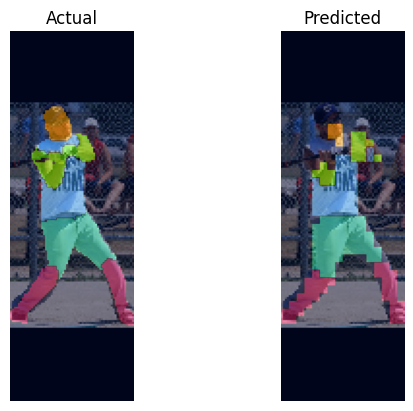

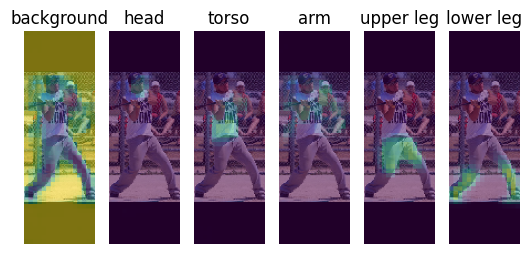

In [7]:
[image, seg] = random.choice(seg_dataset)
model.eval()

seg_result, _ = model(image.to(Config.device).unsqueeze(0))
out_seg = seg_result[0]
cmap = plt.get_cmap('viridis')

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.axis(False)
ax1.title.set_text("Actual")
ax1.imshow(image.permute(1, 2, 0))

seg_hm = seg.unsqueeze(-1).expand(-1, -1, -1, 4) * colors

for i in range(Config.segment_num):
    rgb = seg_hm[i]
    ax1.imshow(rgb)

ax2.axis(False)
ax2.title.set_text("Predicted")
ax2.imshow(image.permute(1, 2, 0))

out_seg = F.interpolate(out_seg, Config.input_resolution, mode="nearest")

out_seg_mask = out_seg.argmax(dim=1)
out_seg_mask = F.one_hot(out_seg_mask, num_classes=Config.segment_num).permute(0, 3, 1, 2)

out_seg_rgb = (out_seg_mask
               .cpu()
               .view(Config.segment_num,
                     Config.input_resolution[0],
                     Config.input_resolution[1], 1)
               .expand(-1, -1, -1, 4) * colors)

for i in range(Config.segment_num):
    rgb = out_seg_rgb[i]
    ax2.imshow(rgb)

fig, axes = plt.subplots(1, Config.segment_num)

for i in range(Config.segment_num):
    ax = axes[i]
    ax.axis(False)
    ax.imshow(image.permute(1, 2, 0))
    label = Config.segment_groups[i]["name"]
    ax.title.set_text(label)
    s = out_seg[0][i]
    rgba = cmap(s.cpu().detach())
    rgba[:,:,-1] = 0.5
    ax.imshow(rgba)

plt.show()

In [8]:
model.eval()

expected_seg = None
predicted_seg = None

with torch.no_grad():
    for images, seg in tqdm(seg_dataloader, desc="Estimate"):
        images = images.to(Config.device)
    
        seg_result, _ = model(images)
        out_seg = seg_result[0]
    
        height = out_seg.shape[2]
        width = out_seg.shape[3]
    
        seg = F.interpolate(seg, (height, width), mode="nearest")
        out_seg = out_seg.cpu().detach()
    
        if expected_seg is None:
            expected_seg = seg
            predicted_seg = out_seg
        else:
            expected_seg = torch.cat((expected_seg, seg), dim=0)
            predicted_seg = torch.cat((predicted_seg, out_seg), dim=0)

Estimate:   0%|          | 0/71 [00:00<?, ?it/s]

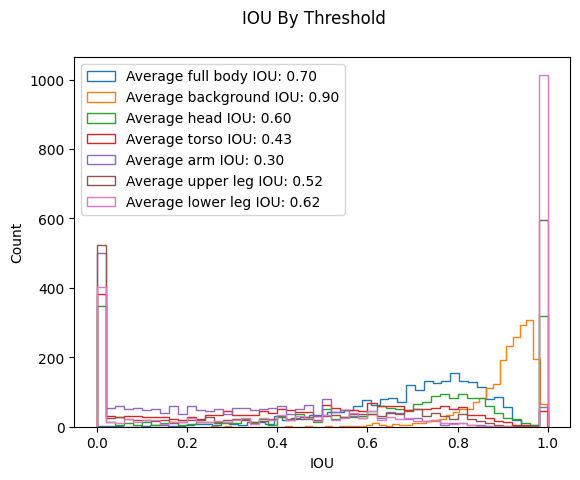

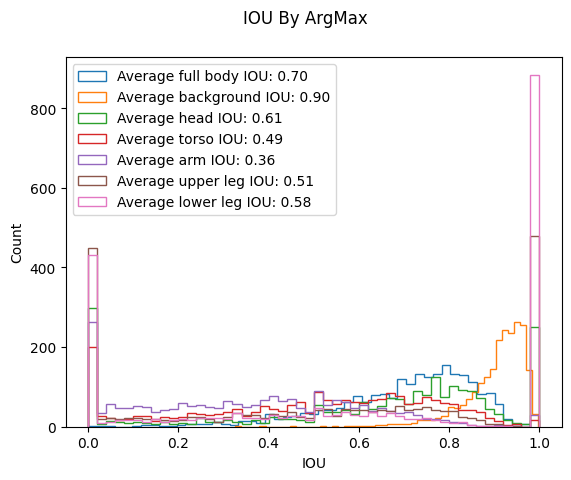

In [9]:
SCORE_THRESHOLD = 0.5
BINS = 50

expected_full_seg_mask = expected_seg[:, [i for i in range(Config.segment_num) if not Config.segment_groups[i]["is_background"]]].sum(dim=1).bool()
expected_seg_mask = expected_seg.bool()

predicted_full_seg = predicted_seg[:, [i for i in range(Config.segment_num) if not Config.segment_groups[i]["is_background"]]].sum(dim=1)

# By Threshold
predicted_full_seg_mask = predicted_full_seg >= SCORE_THRESHOLD
predicted_seg_mask = predicted_seg >= SCORE_THRESHOLD

full_seg_and = torch.logical_and(expected_full_seg_mask, predicted_full_seg_mask).int().sum(dim=1).sum(dim=1)
full_seg_or = torch.logical_or(expected_full_seg_mask, predicted_full_seg_mask).int().sum(dim=1).sum(dim=1)
full_seg_iou = torch.where(full_seg_or == 0.0, 1.0, full_seg_and / full_seg_or)
full_seg_iou_avg = full_seg_iou.sum() / full_seg_iou.shape[0]

seg_and = torch.logical_and(expected_seg_mask, predicted_seg_mask).int().sum(dim=2).sum(dim=2)
seg_or = torch.logical_or(expected_seg_mask, predicted_seg_mask).int().sum(dim=2).sum(dim=2)
seg_iou = torch.where(seg_or == 0.0, 1.0, seg_and / seg_or)
seg_iou_avg = seg_iou.sum(dim=0) / seg_iou.shape[0]


fig, ax = plt.subplots(1, 1)
fig.suptitle("IOU By Threshold")

ax.hist(full_seg_iou.sort().values,
        label=f"Average full body IOU: {full_seg_iou_avg.item():.2f}",
        bins=BINS, histtype="step")
for i in range(Config.segment_num):
    ax.hist(seg_iou[:,i].sort().values,
            label=f"Average {Config.segment_groups[i]['name']} IOU: {seg_iou_avg[i].item():.2f}",
            bins=BINS, histtype="step")
ax.legend(loc='best')
ax.set_xlabel("IOU")
ax.set_ylabel("Count")

# By ArgMax
predicted_bg_seg = predicted_seg[:, [i for i in range(Config.segment_num) if Config.segment_groups[i]["is_background"]]].sum(dim=1)
predicted_full_seg_mask = predicted_full_seg > predicted_bg_seg

predicted_seg_mask = predicted_seg.argmax(dim=1)
predicted_seg_mask = F.one_hot(predicted_seg_mask, num_classes=Config.segment_num).permute(0, 3, 1, 2).bool()

full_seg_and = torch.logical_and(expected_full_seg_mask, predicted_full_seg_mask).int().sum(dim=1).sum(dim=1)
full_seg_or = torch.logical_or(expected_full_seg_mask, predicted_full_seg_mask).int().sum(dim=1).sum(dim=1)
full_seg_iou = torch.where(full_seg_or == 0.0, 1.0, full_seg_and / full_seg_or)
full_seg_iou_avg = full_seg_iou.sum() / full_seg_iou.shape[0]

seg_and = torch.logical_and(expected_seg_mask, predicted_seg_mask).int().sum(dim=2).sum(dim=2)
seg_or = torch.logical_or(expected_seg_mask, predicted_seg_mask).int().sum(dim=2).sum(dim=2)
seg_iou = torch.where(seg_or == 0.0, 1.0, seg_and / seg_or)
seg_iou_avg = seg_iou.sum(dim=0) / seg_iou.shape[0]

fig, ax = plt.subplots(1, 1)
fig.suptitle("IOU By ArgMax")

ax.hist(full_seg_iou.sort().values,
        label=f"Average full body IOU: {full_seg_iou_avg.item():.2f}",
        bins=BINS, histtype="step")
for i in range(Config.segment_num):
    ax.hist(seg_iou[:,i].sort().values,
            label=f"Average {Config.segment_groups[i]['name']} IOU: {seg_iou_avg[i].item():.2f}",
            bins=BINS, histtype="step")
ax.legend(loc='best')
ax.set_xlabel("IOU")
ax.set_ylabel("Count")

plt.show()

### Re-ID Test

In [4]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src.data import get_re_id_test_data
import random
import numpy as np

In [5]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=True,
                  backbone_pretrained=False).to(Config.device)

In [6]:
re_id_dataset, re_id_dataloader = get_re_id_test_data(Config.batch_size,
                                                      Config.input_resolution)

In [7]:
gradcam_model = model.get_gradcam_model().to(Config.device)
colormap = plt.get_cmap('viridis')
colors = [vsg["color"] for vsg in Config.attention_groups]
colors = torch.tensor(colors).unsqueeze(1).unsqueeze(1).expand(Config.attention_num, Config.input_resolution[0], Config.input_resolution[1] * 2, 4)

In [8]:
def matrix2d_to_rgb_heatmap(matrix):
    heatmap_rgba = colormap(matrix)

    if len(heatmap_rgba.shape) == 4:
        heatmap_rgba[:,:,:,-1] = 0.5
    else:
        heatmap_rgba[:,:,-1] = 0.5

    return heatmap_rgba

def compare_visually(idx1, idx2):
    input1 = re_id_dataset[idx1][0].to(Config.device)

    input2 = re_id_dataset[idx2][0].to(Config.device)

    att, v_scores, emb_vecs, activation_maps = gradcam_model(input1,
                                                       input2,
                                                       output_shape=Config.input_resolution)

    det = F.interpolate(att, Config.input_resolution, mode="bilinear")
    det = det.sum(dim=1)
    det = matrix2d_to_rgb_heatmap(det.cpu().detach())
    det = np.concatenate(det, axis=1)

    total_s_score, part_s_scores = Config.similarity_func((v_scores[0], emb_vecs[0]),
                                                          (v_scores[1], emb_vecs[1]),
                                                          return_part_scores=True)

    fig, (ax1, ax2) = plt.subplots(1, 2)

    ax1.title.set_text('Original Pictures')
    ax1.axis(False)
    ax1.imshow(torch.cat((input1.permute(1, 2, 0), input2.permute(1, 2, 0)), dim=1).cpu())
    ax1.text(Config.input_resolution[1], Config.input_resolution[0] + 10,
             f"Similarity Score: {total_s_score.item():.2f}", horizontalalignment='center')

    ax2.title.set_text('Detected Person')
    ax2.axis(False)
    ax2.imshow(torch.cat((input1.permute(1, 2, 0), input2.permute(1, 2, 0)), dim=1).cpu())
    ax2.imshow(det)

    for i in range(Config.attention_num):
        att_map = att[:, i]
        name = Config.attention_groups[i]["name"].title()

        att_map = F.interpolate(att_map.unsqueeze(0), Config.input_resolution, mode="bilinear").squeeze(0)
        att_map = matrix2d_to_rgb_heatmap(att_map.cpu().detach())
        att_map = np.concatenate(att_map, axis=1)

        maps = activation_maps[i]
        maps = matrix2d_to_rgb_heatmap(maps)
        maps = np.concatenate(maps, axis=1)

        fig, (ax1, ax2) = plt.subplots(1, 2)

        fig.suptitle(f'Comparison by parts: {name}')

        ax1.title.set_text('Segment Heatmap')
        ax1.axis(False)
        ax1.imshow(torch.cat((input1.permute(1, 2, 0), input2.permute(1, 2, 0)), dim=1).cpu())
        ax1.imshow(att_map)
        ax1.text(0.5 * Config.input_resolution[1], Config.input_resolution[0] + 10,
                 f"Vis Score: {v_scores[0, i].item():.2f}", horizontalalignment='center')
        ax1.text(Config.input_resolution[1] + 0.5 * Config.input_resolution[1], Config.input_resolution[0] + 10,
                 f"Vis Score: {v_scores[1, i].item():.2f}", horizontalalignment='center')

        ax2.title.set_text('Similarity')
        ax2.axis(False)
        ax2.imshow(torch.cat((input1.permute(1, 2, 0), input2.permute(1, 2, 0)), dim=1).cpu())
        ax2.imshow(maps)
        ax2.text(Config.input_resolution[1], Config.input_resolution[0] + 10,
                 f"Similarity Score: {part_s_scores[i].item():.2f}", horizontalalignment='center')

    plt.show()

Different Identity Comparison Result:


/home/juhonam/workspace/realtime-re-id/re-id/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


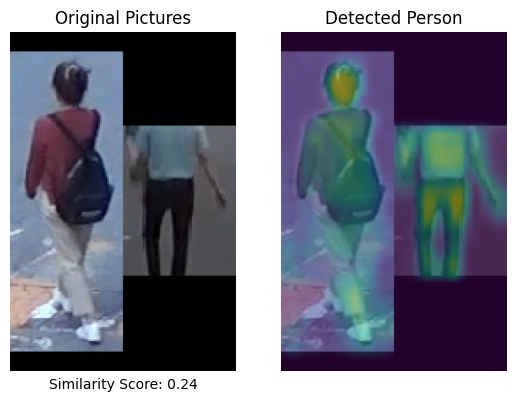

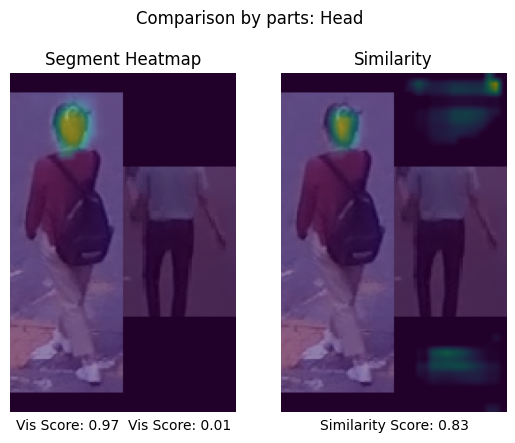

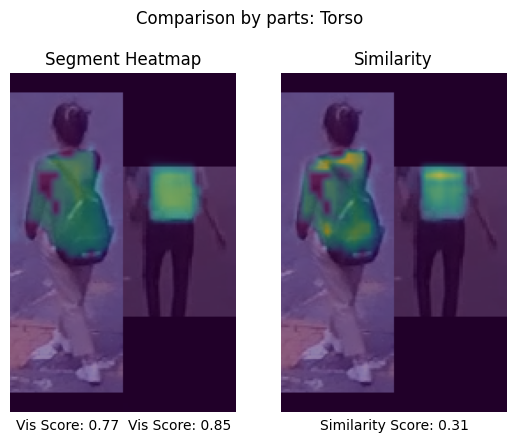

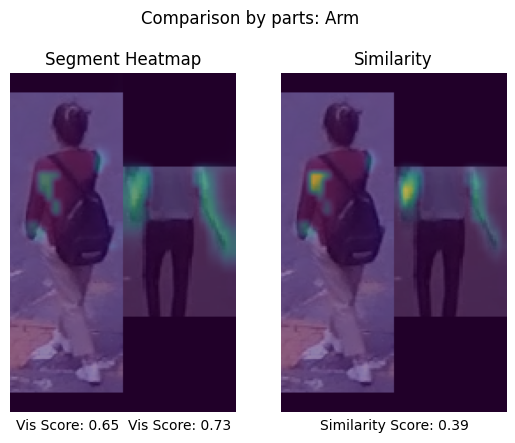

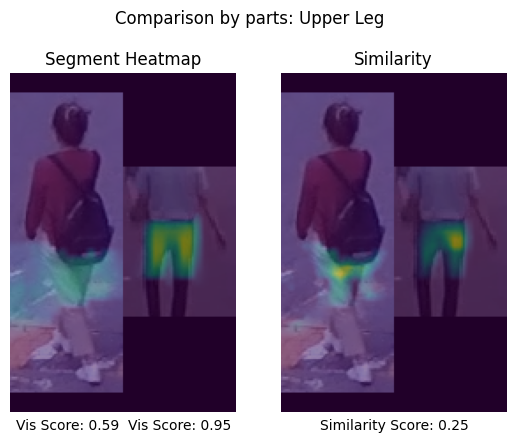

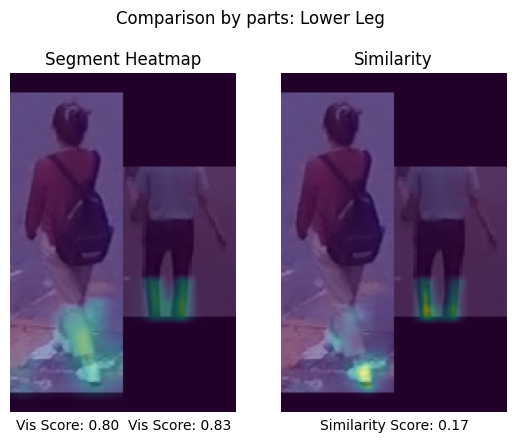

In [9]:
[id1, id2] = random.sample(re_id_dataset.unique_ids, k=2)
idx1 = random.choice(re_id_dataset.get_indexes_by_id(id1))
idx2 = random.choice(re_id_dataset.get_indexes_by_id(id2))

print("Different Identity Comparison Result:")
compare_visually(idx1, idx2)

Same Identity Comparison Result:


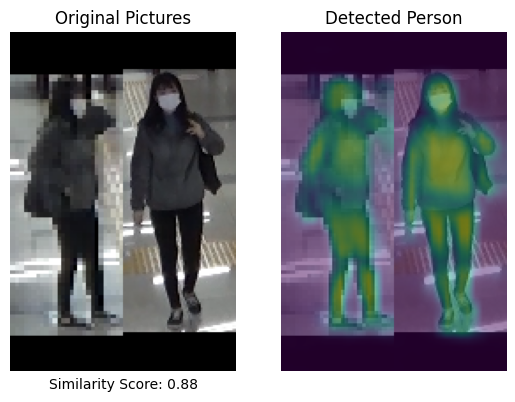

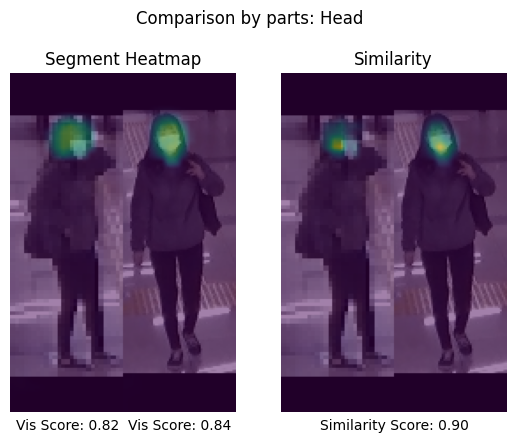

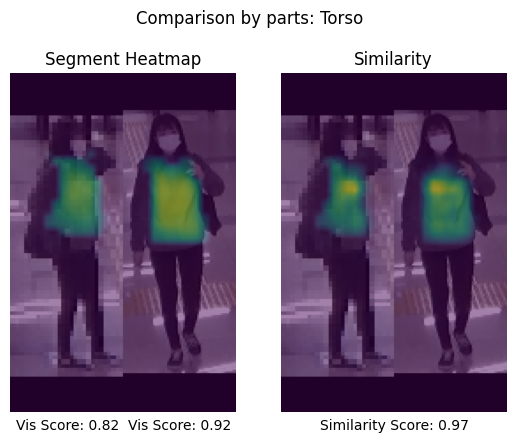

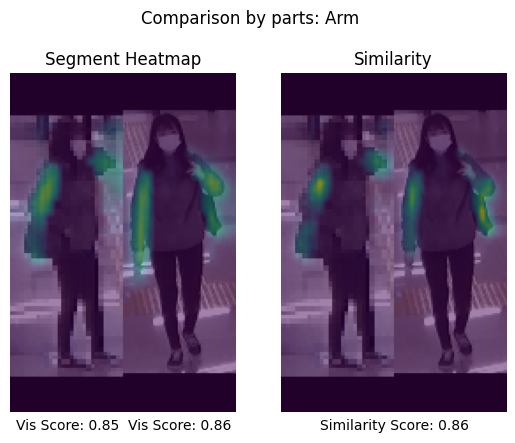

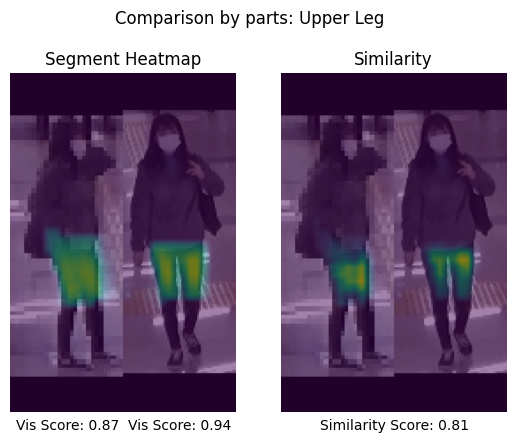

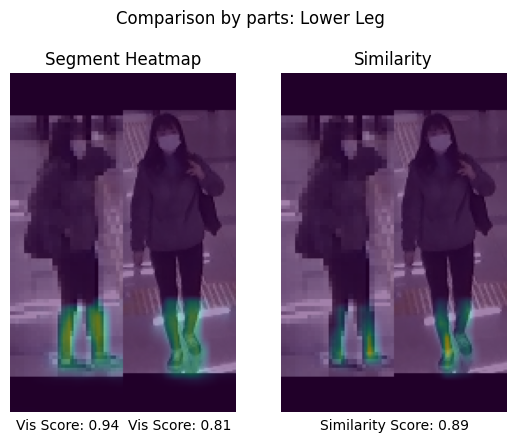

In [10]:
id_ = random.choice(re_id_dataset.unique_ids)
[idx1, idx2] = random.sample(re_id_dataset.get_indexes_by_id(id_), k=2)

print("Same Identity Comparison Result:")
compare_visually(idx1, idx2)

In [11]:
V_SCORE_THRESHOLD = 0.5

y_true = [[] for _ in range(Config.attention_num + Config.all_similarity.metric_num)]
y_pred = [[] for _ in range(Config.attention_num + Config.all_similarity.metric_num)]

unique_ids = re_id_dataset.unique_ids

model.eval()
v_scores = torch.FloatTensor()
emb_vecs = torch.FloatTensor()

with torch.no_grad():
    for (inputs, _) in tqdm(re_id_dataloader, desc="Get Features"):
        input_img = inputs.to(Config.device)
        _, out_ft = model(input_img)
        v_scores = torch.cat((v_scores, out_ft[0].data.cpu()), 0)
        emb_vecs = torch.cat((emb_vecs, out_ft[1].data.cpu()), 0)

for i in tqdm(range(len(unique_ids)), desc="Get Scores"):
    id_ = unique_ids[i]

    indexes = re_id_dataset.get_indexes_by_id(id_)

    for j in range(len(indexes)):
        for is_same_person in [True, False]:
            # Same Person Comparison
            if is_same_person:
                idx1 = indexes[j]
        
                camera = re_id_dataset.get_camera_by_index(idx1)
        
                all_cam = []
                diff_cam = []
                for l in range(len(indexes) - 1):
                    l_ = l + 1 if l >= j else l
        
                    all_cam.append(l_)
                    if re_id_dataset.get_camera_by_index(indexes[l_]) != camera:
                        diff_cam.append(l_)

                # Prioritize images from different cameras
                k = random.choice(diff_cam) if len(diff_cam) > 0 else random.choice(all_cam)
                idx2 = indexes[k]
                y = 1

            # Different People Comparison
            else:
                k = random.choice(range(len(unique_ids) - 1))
                if k >= i:
                    k += 1
                idx1 = indexes[j]
                idx2 = random.choice(re_id_dataset.get_indexes_by_id(unique_ids[k]))
                y = 0

            total_s_scores, part_s_scores = Config.all_similarity((v_scores[idx1], emb_vecs[idx1]),
                                                                  (v_scores[idx2], emb_vecs[idx2]))

            for s_idx, total_s_score in enumerate(total_s_scores):
                y_pred[s_idx].append(total_s_score.item())
                y_true[s_idx].append(y)

            min_v_scores = torch.cat((v_scores[idx1].unsqueeze(0), v_scores[idx2].unsqueeze(0)), dim=0).min(dim=0).values

            for att_idx in range(Config.attention_num):
                v_score = min_v_scores[att_idx].item()
                if v_score < V_SCORE_THRESHOLD:
                    continue
                y_pred[att_idx + Config.all_similarity.metric_num].append(part_s_scores[att_idx].item())
                y_true[att_idx + Config.all_similarity.metric_num].append(y)

emb_vecs = emb_vecs.numpy()

# Move to Stat Report to see the result.

Get Features:   0%|          | 0/3731 [00:00<?, ?it/s]

Get Scores:   0%|          | 0/500 [00:00<?, ?it/s]

## ONNX Export

In [4]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=True,
                  backbone_pretrained=False).to(Config.device)

In [5]:
export_model = model.export().to(Config.device).eval()

dummy_input = torch.randn(1, 3, Config.input_resolution[0], Config.input_resolution[1]).to(Config.device)

os.makedirs(os.path.dirname(model.onnx_export_file_path), exist_ok=True)

torch.onnx.export(
    export_model,
    dummy_input,
    model.onnx_export_file_path,
    export_params=True,
    external_data=False,
    opset_version=18,
    do_constant_folding=True,
    input_names=[Config.input_name],
    output_names=[Config.v_score_name, Config.emb_vec_name],
    dynamic_axes={Config.input_name   : {0 : 'batch_size'},
                  Config.v_score_name : {0 : 'batch_size'},
                  Config.emb_vec_name  : {0 : 'batch_size'}}
)

print("Export Completed")

/tmp/ipykernel_58953/1120954792.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ReIDExportModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ReIDExportModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Export Completed


### Test Exported Model

In [6]:
import onnx
import onnxruntime as ort
from src.data import get_re_id_test_data
import matplotlib.pyplot as plt
import numpy as np
import random

In [7]:
exported_model = onnx.load(model.onnx_export_file_path)

try:
    onnx.checker.check_model(exported_model)
    print("ONNX model is valid!")
    print(f"ONNX Model IR Version: {exported_model.ir_version}")
    for opset in exported_model.opset_import:
        print(f"Domain: {opset.domain}, Version: {opset.version}")
except onnx.checker.ValidationError as e:
    print(f"ONNX model validation failed: {e}")

ONNX model is valid!
ONNX Model IR Version: 10
Domain: , Version: 18


In [8]:
ort_session = ort.InferenceSession(model.onnx_export_file_path)

  0%|          | 0/3731 [00:00<?, ?it/s]

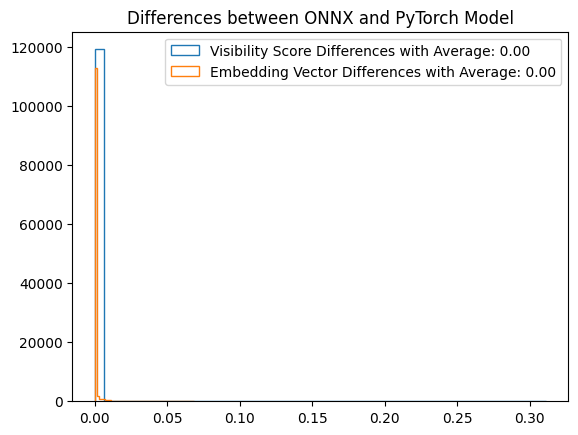

In [9]:
re_id_dataset, re_id_dataloader = get_re_id_test_data(Config.batch_size,
                                                      Config.input_resolution)

v_diff = []
f_diff = []

count = 0

onnx_v_scores = None
onnx_emb_vecs = None

with torch.no_grad():
    for input_batch, _ in tqdm(re_id_dataloader):
        ort_v_scores, ort_emb_vecs = ort_session.run([Config.v_score_name, Config.emb_vec_name], {Config.input_name: input_batch.numpy()})
    
        if onnx_v_scores is None:
            onnx_v_scores = ort_v_scores
        else:
            onnx_v_scores = np.concatenate((onnx_v_scores, ort_v_scores), axis=0)
    
        if onnx_emb_vecs is None:
            onnx_emb_vecs = ort_emb_vecs
        else:
            onnx_emb_vecs = np.concatenate((onnx_emb_vecs, ort_emb_vecs), axis=0)
    
        trc_v_scores, trc_emb_vecs = export_model(input_batch.to(Config.device))
    
        ort_v_scores = torch.tensor(ort_v_scores).to(Config.device)
        ort_emb_vecs = torch.tensor(ort_emb_vecs).to(Config.device)
    
        for i in range(len(trc_emb_vecs)):
            ov = ort_v_scores[i]
            tv = trc_v_scores[i]
    
            oe = ort_emb_vecs[i]
            te = trc_emb_vecs[i]
    
            f_diff.append((torch.norm(te - oe) / torch.norm(te)).item())
    
            v_diff.append((torch.norm(tv - ov) / torch.norm(tv)).item())

plt.title("Differences between ONNX and PyTorch Model")

plt.hist(v_diff, label=f"Visibility Score Differences with Average: {sum(v_diff)/len(v_diff):.2f}", bins=50, histtype="step")
plt.hist(f_diff, label=f"Embedding Vector Differences with Average: {sum(f_diff)/len(f_diff):.2f}", bins=50, histtype="step")

plt.legend(loc="best")

plt.show()

In [10]:
V_SCORE_THRESHOLD = 0.5

y_true = [[] for _ in range(Config.attention_num + Config.all_similarity.metric_num)]
y_pred = [[] for _ in range(Config.attention_num + Config.all_similarity.metric_num)]

unique_ids = re_id_dataset.unique_ids

for i in tqdm(range(len(unique_ids)), desc="Get Scores"):
    id_ = unique_ids[i]

    indexes = re_id_dataset.get_indexes_by_id(id_)

    for j in range(len(indexes)):
        for is_same_person in [True, False]:
            # Same Person Comparison
            if is_same_person:
                idx1 = indexes[j]

                camera = re_id_dataset.get_camera_by_index(idx1)

                all_cam = []
                diff_cam = []
                for l in range(len(indexes) - 1):
                    l_ = l + 1 if l >= j else l

                    all_cam.append(l_)
                    if re_id_dataset.get_camera_by_index(indexes[l_]) != camera:
                        diff_cam.append(l_)

                k = random.choice(diff_cam) if len(diff_cam) > 0 else random.choice(all_cam)
                idx2 = indexes[k]
                y = 1

            # Different People Comparison
            else:
                k = random.choice(range(len(unique_ids) - 1))
                if k >= i:
                    k += 1
                idx1 = indexes[j]
                idx2 = random.choice(re_id_dataset.get_indexes_by_id(unique_ids[k]))
                y = 0

            total_s_scores, part_s_scores = Config.all_similarity((torch.tensor(onnx_v_scores[idx1]),
                                                                   torch.tensor(onnx_emb_vecs[idx1])),
                                                                  (torch.tensor(onnx_v_scores[idx2]),
                                                                   torch.tensor(onnx_emb_vecs[idx2])))

            for s_idx, total_s_score in enumerate(total_s_scores):
                y_pred[s_idx].append(total_s_score.item())
                y_true[s_idx].append(y)

            min_v_scores = np.concatenate((np.expand_dims(onnx_v_scores[idx1], axis=0),
                                           np.expand_dims(onnx_v_scores[idx2], axis=0)),
                                          axis=0).min(axis=0)

            for att_idx in range(Config.attention_num):
                v_score = min_v_scores[att_idx].item()
                if v_score < V_SCORE_THRESHOLD:
                    continue
                y_pred[att_idx + Config.all_similarity.metric_num].append(part_s_scores[att_idx].item())
                y_true[att_idx + Config.all_similarity.metric_num].append(y)

emb_vecs = onnx_emb_vecs

# Move to Stat Report to see the result.

Get Scores:   0%|          | 0/500 [00:00<?, ?it/s]

## Stat Report

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import numpy as np

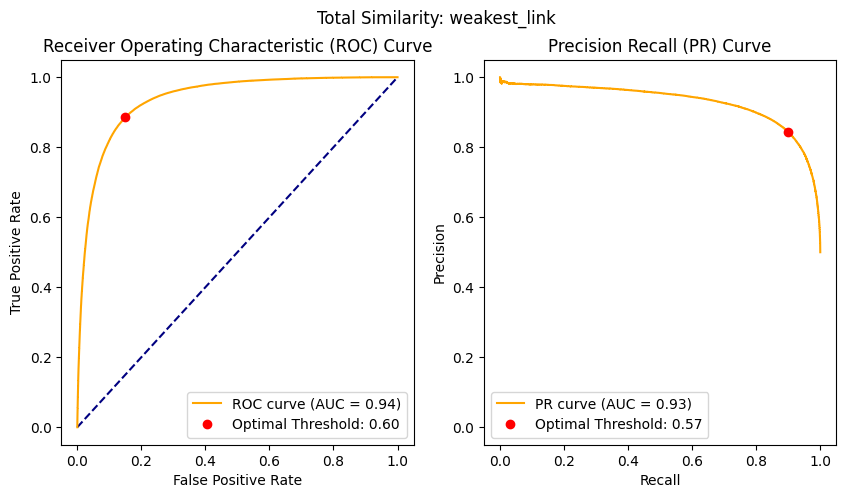

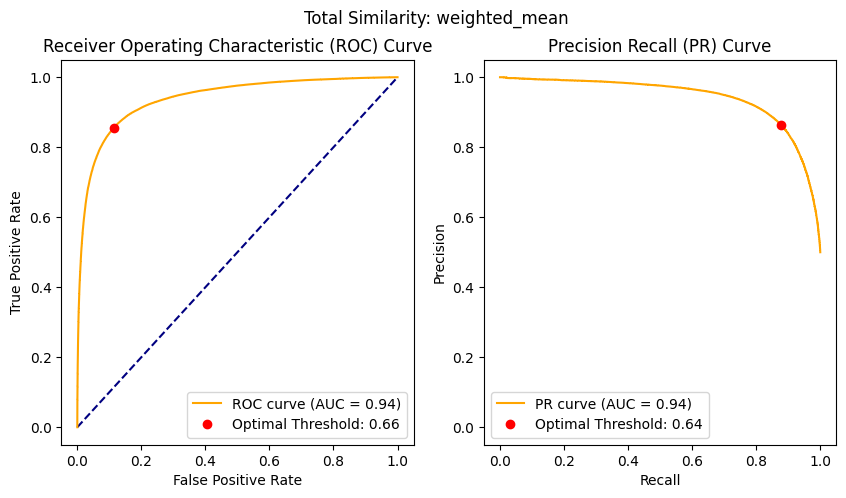

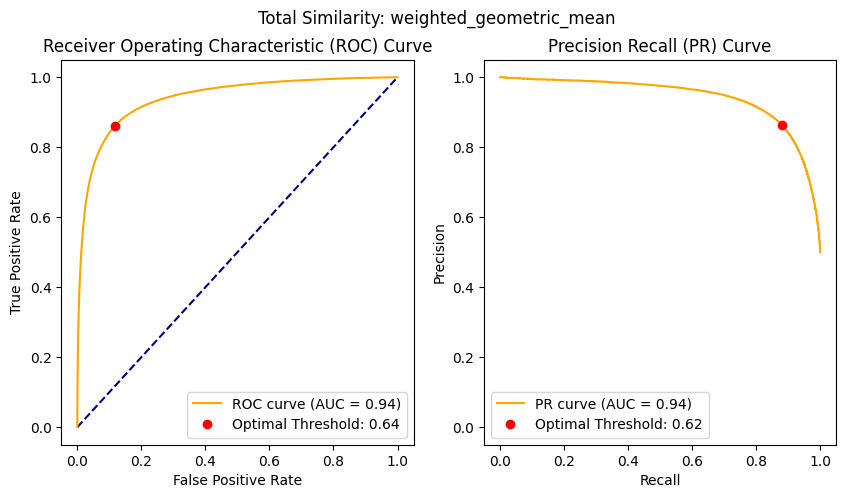

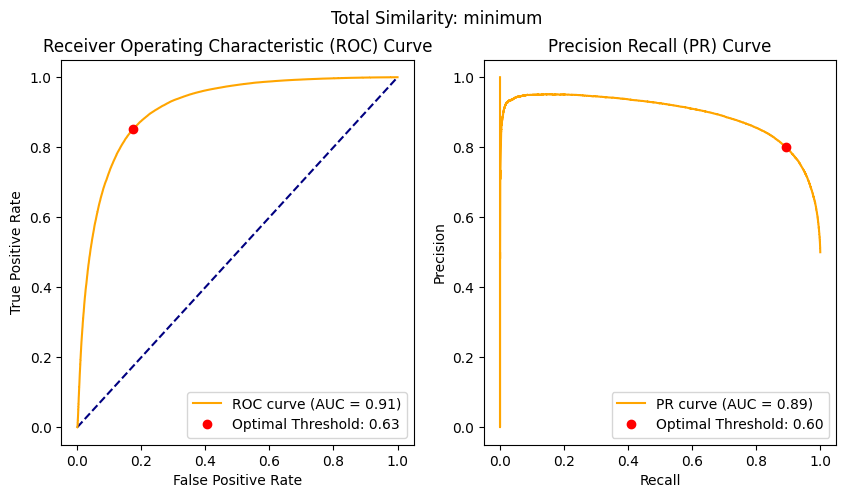

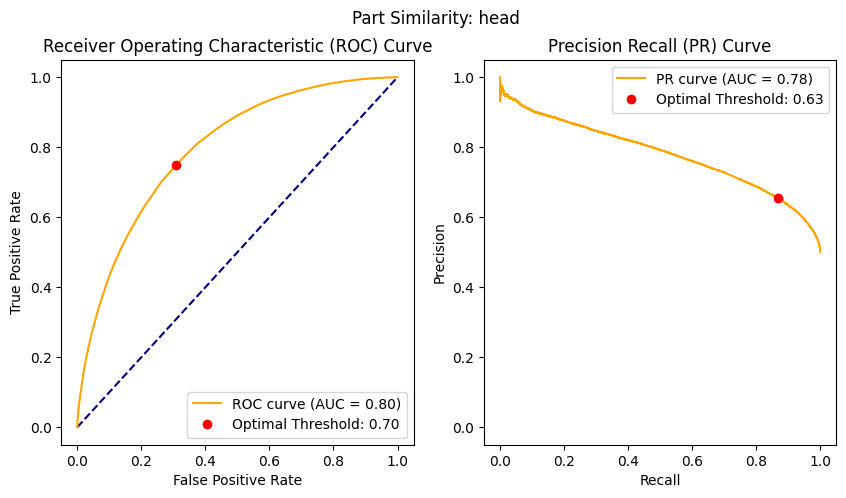

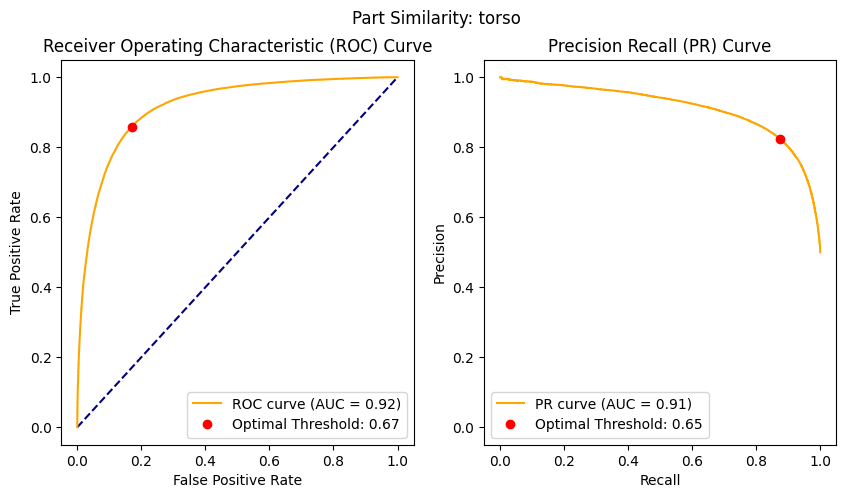

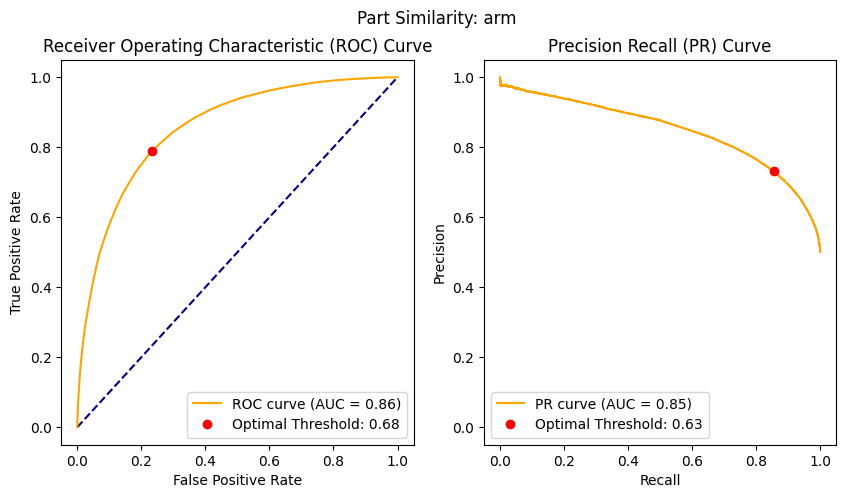

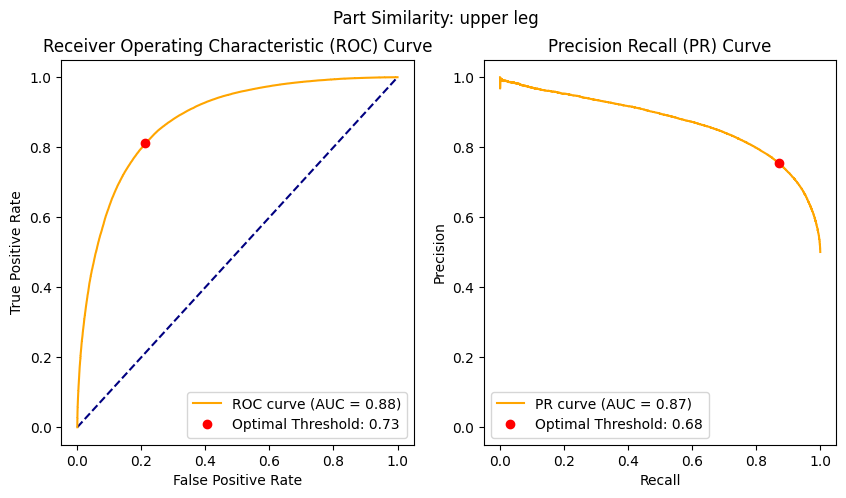

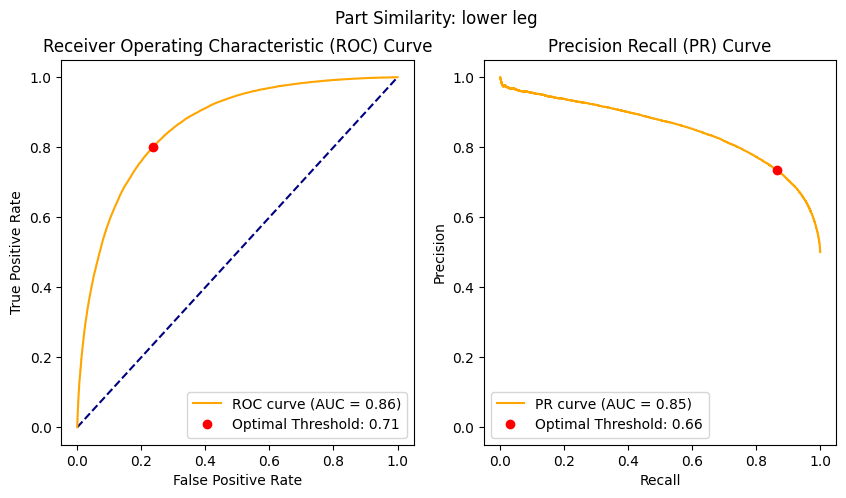

In [12]:
for idx in range(Config.attention_num + Config.all_similarity.metric_num):
    title = (f"Total Similarity: {Config.all_similarity.similarity_metrics[idx]}" if idx < Config.all_similarity.metric_num
             else f"Part Similarity: {Config.attention_groups[idx - Config.all_similarity.metric_num]['name']}")

    fpr, tpr, thresholds = roc_curve(y_true[idx], y_pred[idx])
    auc_score = auc(fpr, tpr)

    curve_color = "orange"
    threshold_point_color = "red"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    fig.suptitle(title)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true[idx], y_pred[idx])
    auc_score = auc(fpr, tpr)
    optimal_idx = (tpr - fpr).argmax()

    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_xlim([-0.05, 1.05])
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_title("Receiver Operating Characteristic (ROC) Curve")
    ax1.plot([0, 1], [0, 1], linestyle='dashed', color='navy')
    ax1.plot(fpr, tpr, color=curve_color, label="ROC curve (AUC = {:.2f})".format(auc_score))
    ax1.plot(fpr[optimal_idx], tpr[optimal_idx], "o", color=threshold_point_color, label="Optimal Threshold: {:.2f}".format(thresholds[optimal_idx]))
    ax1.legend(loc='best')

    #PR Curve
    precision, recall, thresholds = precision_recall_curve(y_true[idx], y_pred[idx])
    auc_score = auc(recall, precision)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = f1_scores.argmax()

    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_xlim([-0.05, 1.05])
    ax2.set_ylim([-0.05, 1.05])
    ax2.set_title("Precision Recall (PR) Curve")
    ax2.plot(recall, precision, color=curve_color, label="PR curve (AUC = {:.2f})".format(auc_score))
    ax2.plot(recall[optimal_idx], precision[optimal_idx], "o", color=threshold_point_color, label="Optimal Threshold: {:.2f}".format(thresholds[optimal_idx]))
    ax2.legend(loc='best')

    plt.show()

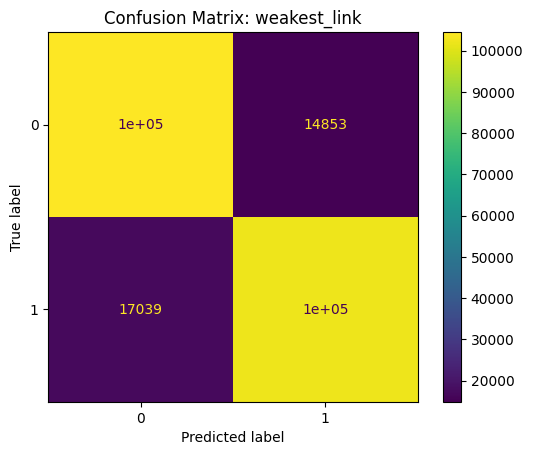

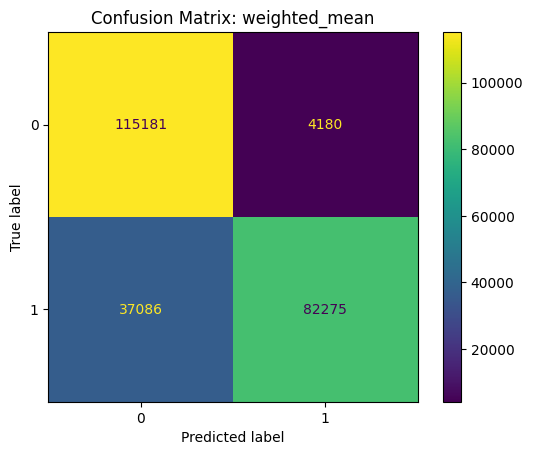

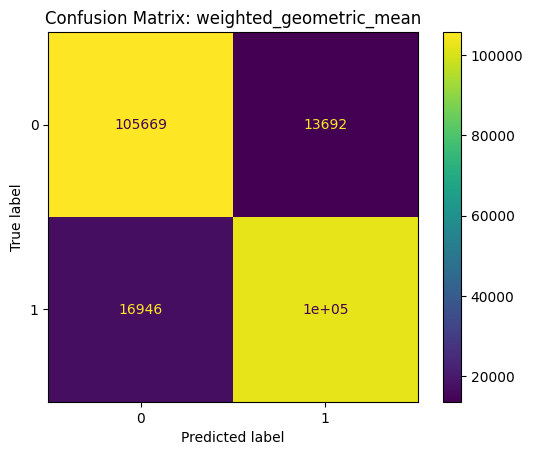

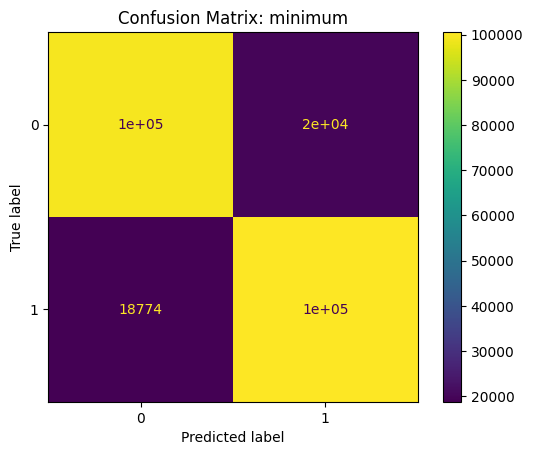

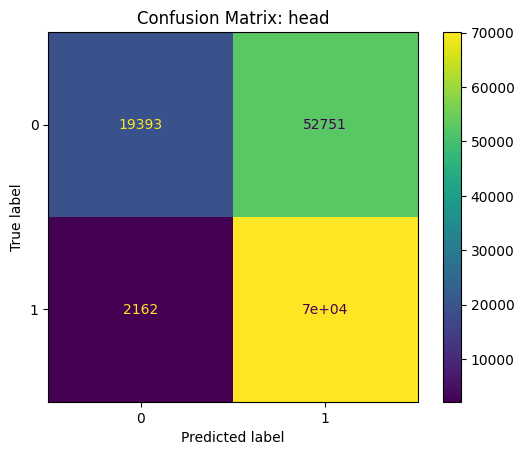

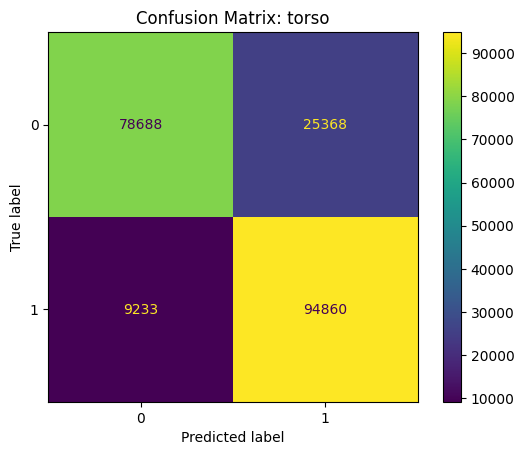

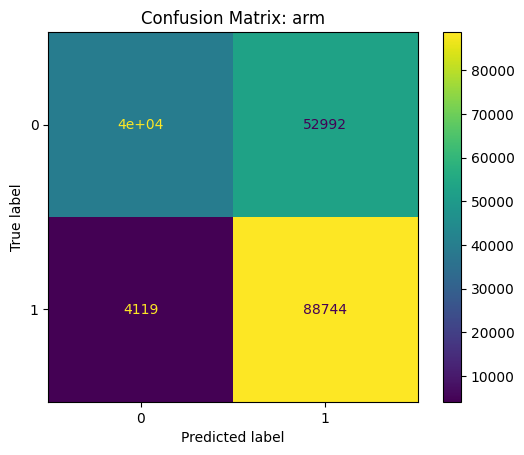

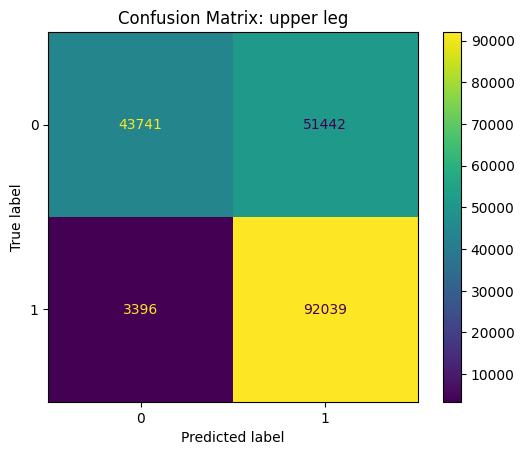

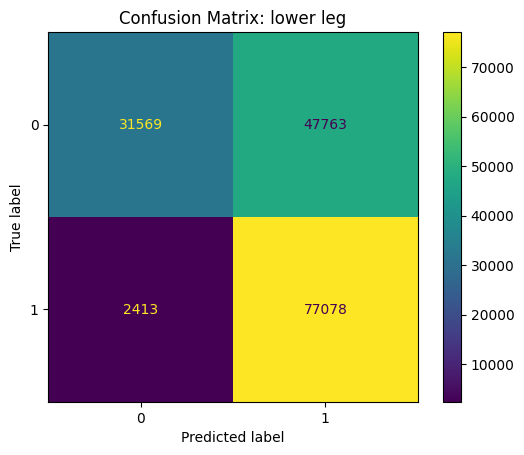

In [13]:
TOTAL_SCORE_THRESHOLDS = Config.all_similarity.default_metric_thresholds
PART_SCORE_THRESHOLDS = Config.default_thresholds

for idx in range(Config.attention_num + Config.all_similarity.metric_num):
    threshold = TOTAL_SCORE_THRESHOLDS[idx] if idx < Config.all_similarity.metric_num else PART_SCORE_THRESHOLDS[idx - Config.all_similarity.metric_num]
    title = (f"Confusion Matrix: {Config.all_similarity.similarity_metrics[idx]}" if idx < Config.all_similarity.metric_num
             else f"Confusion Matrix: {Config.attention_groups[idx - Config.all_similarity.metric_num]['name']}")

    disp = ConfusionMatrixDisplay(confusion_matrix(y_true[idx], [0 if y < threshold else 1 for y in y_pred[idx]]))
    disp.plot()
    disp.ax_.set_title(title)
    plt.show()

In [14]:
for idx in range(Config.attention_num + Config.all_similarity.metric_num):
    threshold = TOTAL_SCORE_THRESHOLDS[idx] if idx < Config.all_similarity.metric_num else PART_SCORE_THRESHOLDS[idx - Config.all_similarity.metric_num]
    title = (f"Classification Report: {Config.all_similarity.similarity_metrics[idx]}" if idx < Config.all_similarity.metric_num
             else f"Classification Report: {Config.attention_groups[idx - Config.all_similarity.metric_num]['name']}")

    report = classification_report(y_true[idx], [0 if y < threshold else 1 for y in y_pred[idx]])
    print()
    print(f"              {title}")
    print()
    print(report)
    print()


              Classification Report: weakest_link

              precision    recall  f1-score   support

           0       0.86      0.88      0.87    119361
           1       0.87      0.86      0.87    119361

    accuracy                           0.87    238722
   macro avg       0.87      0.87      0.87    238722
weighted avg       0.87      0.87      0.87    238722



              Classification Report: weighted_mean

              precision    recall  f1-score   support

           0       0.76      0.96      0.85    119361
           1       0.95      0.69      0.80    119361

    accuracy                           0.83    238722
   macro avg       0.85      0.83      0.82    238722
weighted avg       0.85      0.83      0.82    238722



              Classification Report: weighted_geometric_mean

              precision    recall  f1-score   support

           0       0.86      0.89      0.87    119361
           1       0.88      0.86      0.87    119361

    accuracy

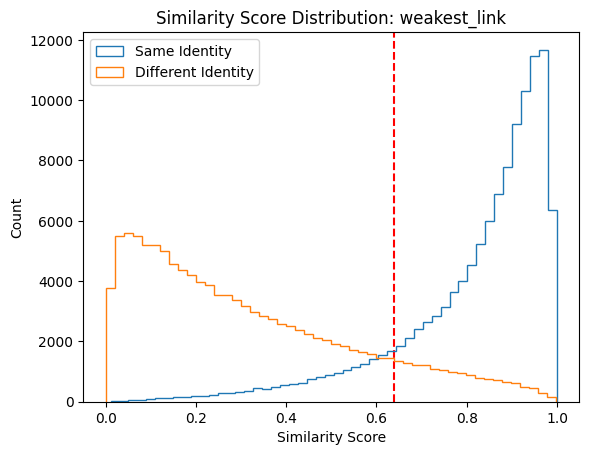

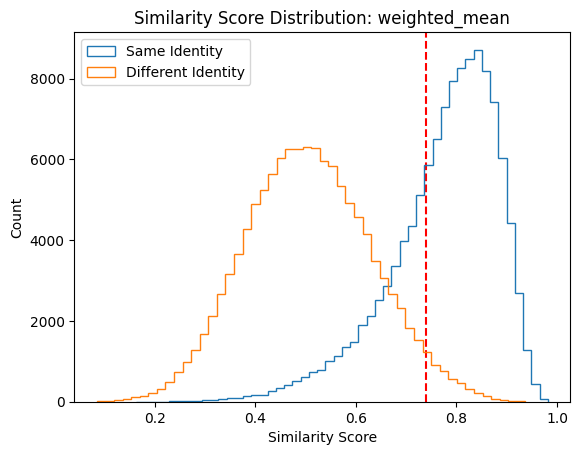

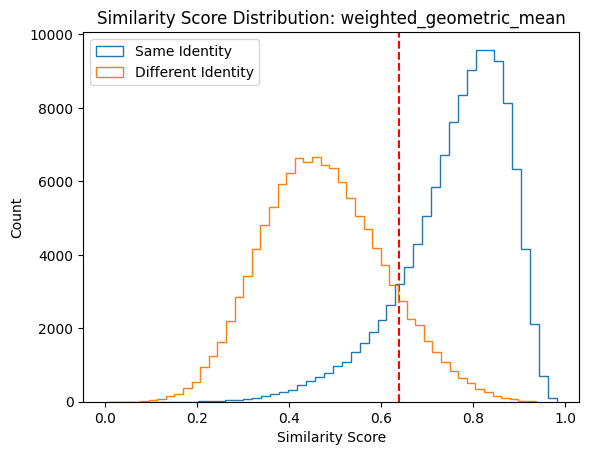

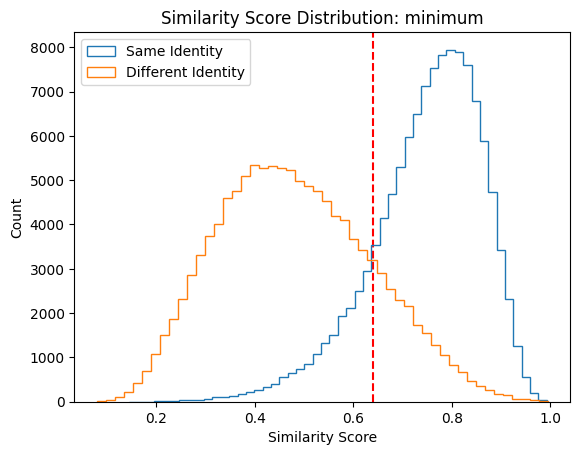

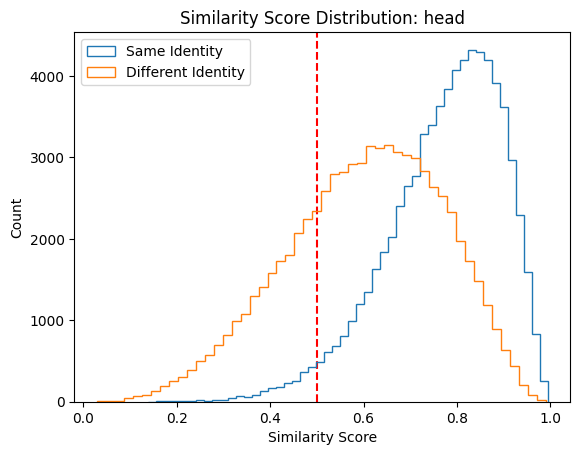

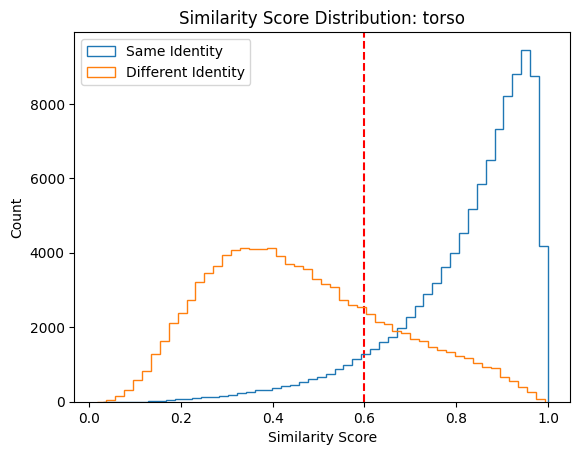

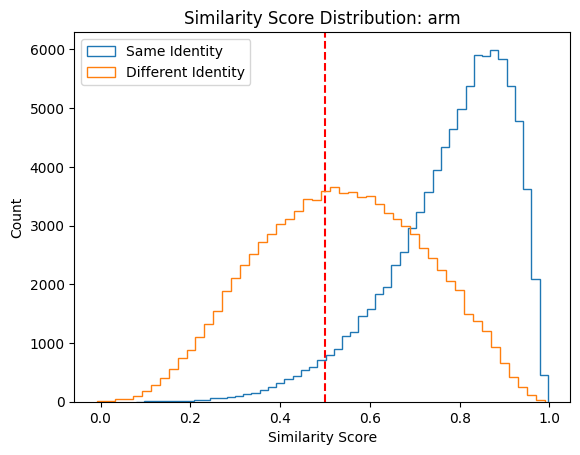

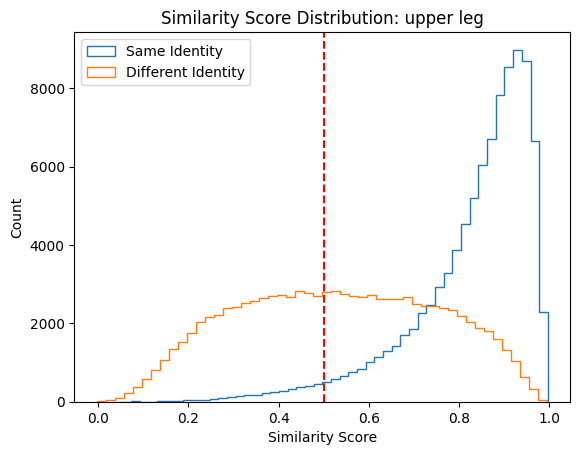

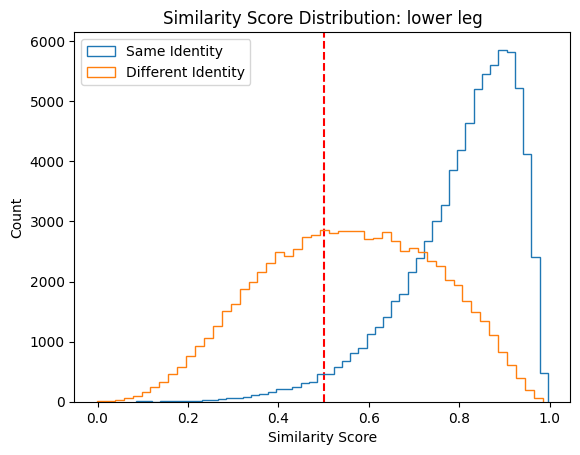

In [15]:
bins = 50

for idx in range(Config.attention_num + Config.all_similarity.metric_num):
    threshold = TOTAL_SCORE_THRESHOLDS[idx] if idx < Config.all_similarity.metric_num else PART_SCORE_THRESHOLDS[idx - Config.all_similarity.metric_num]
    title = (f"Similarity Score Distribution: {Config.all_similarity.similarity_metrics[idx]}" if idx < Config.all_similarity.metric_num
             else f"Similarity Score Distribution: {Config.attention_groups[idx - Config.all_similarity.metric_num]['name']}")

    y_true_scores = []
    y_false_scores = []

    for i in range(len(y_true[idx])):
        if y_true[idx][i]:
            y_true_scores.append(y_pred[idx][i])
        else:
            y_false_scores.append(y_pred[idx][i])

    y_true_scores.sort()
    y_false_scores.sort()

    plt.axvline(x=threshold, color='r', linestyle='dashed')

    plt.hist(y_true_scores,
             label="Same Identity",
             bins=50, histtype="step")
    plt.hist(y_false_scores,
             label="Different Identity",
             bins=50, histtype="step")

    plt.xlabel("Similarity Score")
    plt.ylabel("Count")
    plt.legend(loc="best")

    plt.title(title)

    plt.show()

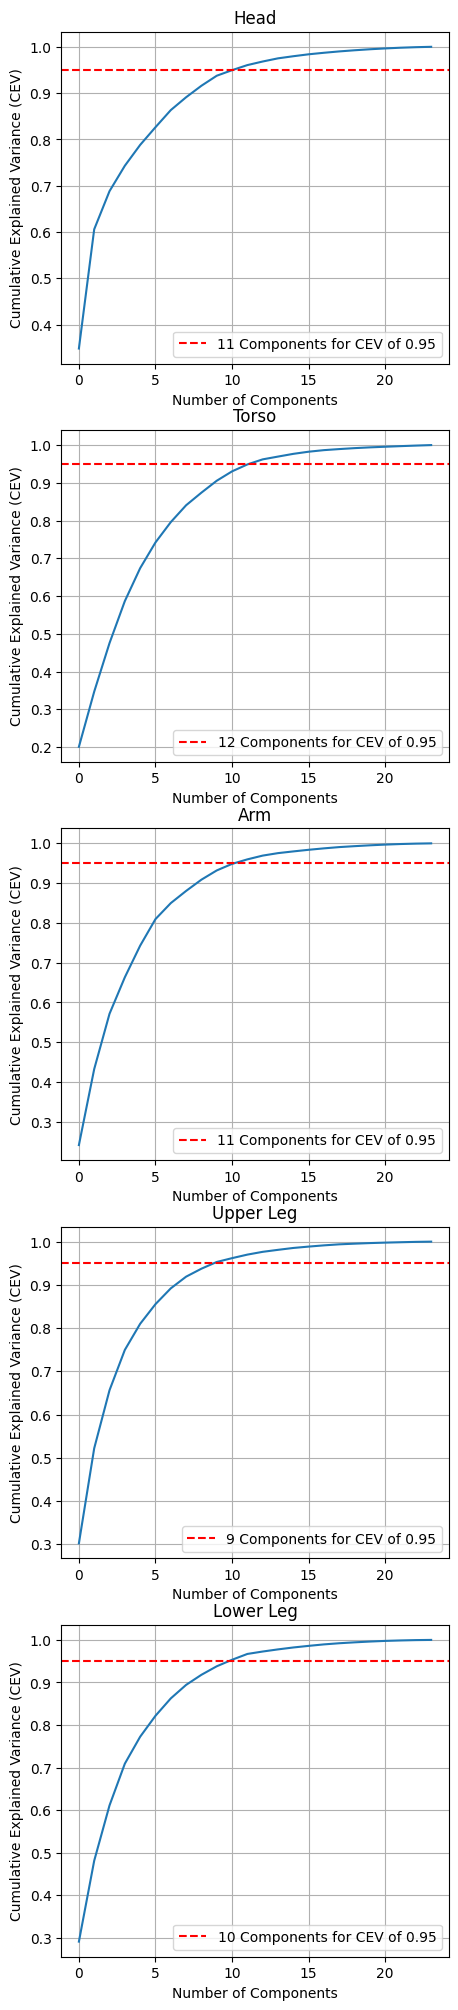

In [16]:
cev_threshold = 0.95

fig, axes = plt.subplots(Config.attention_num, 1, figsize=(5, 5 * Config.attention_num))

for i in range(Config.attention_num):
    name = Config.attention_groups[i]["name"].title()
    ax = axes[i]
    data = emb_vecs[:, i]
    pca = PCA().fit(data)
    cev = np.cumsum(pca.explained_variance_ratio_)

    c = next(i for i, x in enumerate(cev) if x >= cev_threshold)

    ax.set_title(name)
    ax.plot(cev)
    ax.axhline(y=cev_threshold, color='r', linestyle='dashed', label=f"{c} Components for CEV of {cev_threshold}")
    ax.set_xlabel("Number of Components")
    ax.set_ylabel("Cumulative Explained Variance (CEV)")
    ax.grid()
    ax.legend(loc='best')

plt.show()